# Data pipeline to process and analyze raster tiles of forest loss within and outside PAs

In [3]:
# Imports
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
from rasterio.windows import from_bounds
from rasterio.features import rasterize
from shapely.geometry import box
import glob

In [2]:
# Data
ape_ranges = gpd.read_file(r"C:\Users\otmil\OneDrive - United Nations\Desktop\Career\Great Ape Conservation Project\Ape_ranges.shp")  
countries = gpd.read_file(r"C:\Users\otmil\OneDrive - United Nations\Desktop\Career\Great Ape Conservation Project\data\ne_10m_admin_0_countries.shp") 

countries = countries.to_crs(ape_ranges.crs)

ape_ranges_by_country = gpd.overlay(ape_ranges, countries[['NAME_LONG', 'geometry']], how='intersection')
ape_ranges_by_country = ape_ranges_by_country.rename(columns={'NAME_LONG': 'country'})

# Confirm it worked
print(ape_ranges_by_country['country'].unique())

['Nigeria' 'Cameroon' 'Republic of the Congo'
 'Democratic Republic of the Congo' 'Central African Republic' 'Angola'
 'Gabon' 'Equatorial Guinea' 'South Sudan' 'Tanzania' 'Burundi' 'Rwanda'
 'Uganda' 'Sierra Leone' 'Guinea' 'Liberia' "Côte d'Ivoire" 'Mali'
 'Senegal' 'Ghana' 'Guinea-Bissau' 'Malaysia' 'Indonesia']


In [4]:
# Proteceted areas data
protected_areas = gpd.read_file(r"C:\Users\otmil\OneDrive - United Nations\Desktop\Career\Great Ape Conservation Project\Ape_PAs.shp")
protected_areas = protected_areas.to_crs(ape_ranges_by_country.crs)
print(protected_areas.total_bounds)
print(ape_ranges_by_country.total_bounds)
print(protected_areas.crs)

C:\Users\OMILLER1\AppData\Local\anaconda3\envs\geo\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


DataSourceError: C:\Users\otmil\OneDrive - United Nations\Desktop\Career\Great Ape Conservation Project\Ape_PAs.shp: No such file or directory

In [7]:
# Analyze tile function 
def analyze_tile(lossyear_path, treecover_path, ape_ranges, protected_areas):

    with rasterio.open(lossyear_path) as src:
        bounds = src.bounds
        tile_bounds = box(bounds.left, bounds.bottom, bounds.right, bounds.top)

    ape_tile = ape_ranges[ape_ranges.intersects(tile_bounds)]
    if len(ape_tile) == 0:
        print(f'No ape ranges in tile — skipping')
        return None

    pa_tile = protected_areas[protected_areas.intersects(tile_bounds)]

    country_data = {}

    for idx, ape_row in ape_tile.iterrows():
        country = ape_row['country']
        geom = ape_row.geometry.intersection(tile_bounds)

        if geom.is_empty:
            continue

        geom = geom.simplify(0.0001, preserve_topology=True)
        geom_bounds = geom.bounds

        if country not in country_data:
            country_data[country] = {
                'year_loss_inside': np.zeros(25, dtype=np.int64),
                'year_loss_outside': np.zeros(25, dtype=np.int64),
                'total_inside': 0,
                'total_outside': 0
            }

        with rasterio.open(lossyear_path) as src:
            window = from_bounds(geom_bounds[0], geom_bounds[1],
                               geom_bounds[2], geom_bounds[3],
                               src.transform)
            loss_chunk = src.read(1, window=window)
            win_transform = src.window_transform(window)

        with rasterio.open(treecover_path) as src:
            window = from_bounds(geom_bounds[0], geom_bounds[1],
                               geom_bounds[2], geom_bounds[3],
                               src.transform)
            tc_chunk = src.read(1, window=window)

        ape_mask = rasterize(
            [(geom, 1)],
            out_shape=loss_chunk.shape,
            transform=win_transform,
            fill=0,
            dtype='uint8'
        )

        pa_here = pa_tile[pa_tile.intersects(geom)]
        if len(pa_here) > 0:
            pa_mask = rasterize(
                [(g, 1) for g in pa_here.geometry],
                out_shape=loss_chunk.shape,
                transform=win_transform,
                fill=0,
                dtype='uint8'
            )
        else:
            pa_mask = np.zeros(loss_chunk.shape, dtype='uint8')

        valid_forest = (ape_mask == 1) & (tc_chunk >= 10) & (tc_chunk != 255) & (loss_chunk != 255)
        inside = valid_forest & (pa_mask == 1)
        outside = valid_forest & (pa_mask == 0)

        country_data[country]['total_inside'] += int(np.sum(inside))
        country_data[country]['total_outside'] += int(np.sum(outside))

        for year_idx in range(1, 26):
            country_data[country]['year_loss_inside'][year_idx-1] += np.count_nonzero((loss_chunk == year_idx) & inside)
            country_data[country]['year_loss_outside'][year_idx-1] += np.count_nonzero((loss_chunk == year_idx) & outside)

        del loss_chunk, tc_chunk, ape_mask, pa_mask, valid_forest, inside, outside

    results = []
    for country, data in country_data.items():
        for year_idx in range(25):
            pct_inside = (data['year_loss_inside'][year_idx] / data['total_inside'] * 100) if data['total_inside'] > 0 else 0
            pct_outside = (data['year_loss_outside'][year_idx] / data['total_outside'] * 100) if data['total_outside'] > 0 else 0
            results.append({
                'country': country,
                'year': 2001 + year_idx,
                'loss_pct_inside_pa': pct_inside,
                'loss_pct_outside_pa': pct_outside,
                'pixels_inside_pa': data['total_inside'],
                'pixels_outside_pa': data['total_outside']
            })

    print(f'Tile complete: {lossyear_path.split(chr(92))[-1]}')
    return pd.DataFrame(results)

In [8]:
#Results

lossyear_files = sorted(glob.glob(r"C:\Users\otmil\OneDrive - United Nations\Desktop\Career\Great Ape Conservation Project\data\Hansen_Spatial\*lossyear*.tif"))

all_results = []

for lossyear_path in lossyear_files:
    treecover_path = lossyear_path.replace('lossyear', 'treecover2000')
    result = analyze_tile(lossyear_path, treecover_path, ape_ranges_by_country, protected_areas)
    if result is not None:
        all_results.append(result)

final_df = pd.concat(all_results, ignore_index=True)

Tile complete: Hansen_GFC-2025-v1.13_lossyear_00N_010E.tif
Tile complete: Hansen_GFC-2025-v1.13_lossyear_00N_020E.tif
Tile complete: Hansen_GFC-2025-v1.13_lossyear_00N_030E.tif
Tile complete: Hansen_GFC-2025-v1.13_lossyear_00N_100E.tif
Tile complete: Hansen_GFC-2025-v1.13_lossyear_00N_110E.tif
No ape ranges in tile — skipping
Tile complete: Hansen_GFC-2025-v1.13_lossyear_10N_000E.tif
Tile complete: Hansen_GFC-2025-v1.13_lossyear_10N_010E.tif
Tile complete: Hansen_GFC-2025-v1.13_lossyear_10N_020E.tif
No ape ranges in tile — skipping
Tile complete: Hansen_GFC-2025-v1.13_lossyear_10N_110E.tif
No ape ranges in tile — skipping
No ape ranges in tile — skipping
No ape ranges in tile — skipping
No ape ranges in tile — skipping


In [11]:
final_df.to_csv(r"C:\Users\otmil\OneDrive - United Nations\Desktop\Career\Great Ape Conservation Project\pa_effectiveness_by_country_raw.csv", index=False)

In [13]:
df = pd.read_csv(r"C:\Users\otmil\OneDrive - United Nations\Desktop\Career\Great Ape Conservation Project\pa_effectiveness_by_country_raw.csv") 

# Step 1: convert % back to raw loss pixel counts
df['loss_pixels_inside'] = (df['loss_pct_inside_pa'] / 100) * df['pixels_inside_pa']
df['loss_pixels_outside'] = (df['loss_pct_outside_pa'] / 100) * df['pixels_outside_pa']

# Step 2: sum everything across tiles, grouped by country + year
summed = df.groupby(['country', 'year'], as_index=False).agg(
    pixels_inside_pa=('pixels_inside_pa', 'sum'),
    pixels_outside_pa=('pixels_outside_pa', 'sum'),
    loss_pixels_inside=('loss_pixels_inside', 'sum'),
    loss_pixels_outside=('loss_pixels_outside', 'sum')
)

# Step 3: recompute correct percentages from the summed totals
summed['loss_pct_inside_pa'] = (summed['loss_pixels_inside'] / summed['pixels_inside_pa']) * 100
summed['loss_pct_outside_pa'] = (summed['loss_pixels_outside'] / summed['pixels_outside_pa']) * 100

# Step 4: export the corrected, combined result
summed.to_csv("pa_effectiveness_by_country_combined.csv", index=False)
print(summed.head(20))

   country  year  pixels_inside_pa  pixels_outside_pa  loss_pixels_inside  \
0   Angola  2001                 0           12946312                 0.0   
1   Angola  2002                 0           12946312                 0.0   
2   Angola  2003                 0           12946312                 0.0   
3   Angola  2004                 0           12946312                 0.0   
4   Angola  2005                 0           12946312                 0.0   
5   Angola  2006                 0           12946312                 0.0   
6   Angola  2007                 0           12946312                 0.0   
7   Angola  2008                 0           12946312                 0.0   
8   Angola  2009                 0           12946312                 0.0   
9   Angola  2010                 0           12946312                 0.0   
10  Angola  2011                 0           12946312                 0.0   
11  Angola  2012                 0           12946312                 0.0   

In [15]:
malaysia_range = ape_ranges_by_country[ape_ranges_by_country['country']=='Malaysia']
malaysia_pas = protected_areas[protected_areas.intersects(malaysia_range.geometry.unary_union)]

print(f"Number of PAs: {len(malaysia_pas)}")
print(f"Ape range area (km²): {malaysia_range.to_crs('EPSG:6933').geometry.area.sum() / 1e6:.1f}")
print(f"PA area (km²): {malaysia_pas.to_crs('EPSG:6933').geometry.area.sum() / 1e6:.1f}")

C:\Users\otmil\AppData\Local\Temp\ipykernel_8844\335386047.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  malaysia_pas = protected_areas[protected_areas.intersects(malaysia_range.geometry.unary_union)]


Number of PAs: 67
Ape range area (km²): 49150.5
PA area (km²): 18523.4


In [1]:
print(protected_areas.shape)
print(protected_areas.columns.tolist())

NameError: name 'protected_areas' is not defined

In [41]:
coverage_results = []

for country in ape_countries:
    country_range = ape_ranges_by_country[ape_ranges_by_country['country'] == country]
    
    # Dissolve overlapping species range polygons into one unified shape
    country_range_dissolved = country_range.dissolve()
    
    country_range_pas = gpd.overlay(
        country_range_dissolved[['geometry']],
        protected_areas[['geometry']],
        how='intersection'
    )
    
    range_ea = country_range_dissolved.to_crs('EPSG:6933')
    overlay_ea = country_range_pas.to_crs('EPSG:6933')
    
    range_area_km2 = range_ea.geometry.area.sum() / 1e6
    pa_overlap_km2 = overlay_ea.geometry.area.sum() / 1e6
    
    coverage_results.append({
        'country': country,
        'range_area_ha': range_area_km2 * 100,
        'pa_area_ha': pa_overlap_km2 * 100,
        'pct_covered': (pa_overlap_km2 / range_area_km2) * 100 if range_area_km2 > 0 else 0
    })

coverage_df = pd.DataFrame(coverage_results)
print(coverage_df)

                             country  range_area_ha    pa_area_ha  pct_covered
0                           Cameroon   2.349081e+07  4.217480e+06    17.953749
1           Central African Republic   1.277954e+07  1.920391e+06    15.027074
2   Democratic Republic of the Congo   1.230251e+08  2.548993e+07    20.719286
3                              Gabon   2.547419e+07  6.705007e+06    26.320786
4                            Nigeria   3.055497e+06  1.962169e+06    64.217664
5              Republic of the Congo   2.467262e+07  1.444342e+07    58.540290
6                             Rwanda   2.551466e+05  1.442229e+05    56.525491
7                            Burundi   6.179705e+05  5.104314e+04     8.259802
8                           Tanzania   1.660321e+06  4.773566e+05    28.750859
9                             Uganda   2.025613e+06  1.289018e+06    63.635945
10                         Indonesia   2.355644e+07  5.066403e+06    21.507511
11                          Malaysia   4.915046e+06 

In [42]:
coverage_df.to_csv(r"C:\Users\otmil\OneDrive - United Nations\Desktop\Career\Great Ape Conservation Project\pa_coverage_by_country.csv", index=False)

In [17]:
print(country_range_pas.geometry.type.value_counts())

MultiPolygon    67
Polygon         48
Name: count, dtype: int64


In [18]:
print(ape_ranges_by_country[ape_ranges_by_country['country'] == 'Nigeria'][['country', 'geometry']].shape)

(2, 2)


In [40]:
import plotly.graph_objects as go

# Convert to Mha for readability
coverage_df['range_area_mha'] = coverage_df['range_area_ha'] / 1_000_000
coverage_df['pa_area_mha'] = coverage_df['pa_area_ha'] / 1_000_000

# Country name shortening (reuse your existing dict)
country_names = {
    'Democratic Republic of the Congo': 'DR Congo',
    'Republic of the Congo': 'Rep. of Congo',
    'Central African Republic': 'Central African Rep.'
}
coverage_df['country'] = coverage_df['country'].replace(country_names)

# Sort by % covered for Tab 1
coverage_sorted = coverage_df.sort_values('pct_covered', ascending=True)

# --- TAB 1: % of ape range within PA, by country ---
fig_coverage_pct = go.Figure()
fig_coverage_pct.add_trace(go.Bar(
    x=coverage_sorted['pct_covered'],
    y=coverage_sorted['country'],
    orientation='h',
    marker=dict(
        color=coverage_sorted['pct_covered'],
        colorscale='RdYlGn',
        cmin=0,
        cmax=70,
        showscale=False
    ),
    hovertemplate='<b>%{y}</b><br>Ape range within PA: %{x:.1f}%<extra></extra>'
))
fig_coverage_pct.update_layout(
    title=dict(
        text='<b>Great ape range within protected areas, by country</b><br>'
             '<sup><i>Percentage of confirmed ape range falling within a protected area boundary</i></sup>',
        x=0.02
    ),
    template='simple_white',
    font_family='Roboto',
    height=600,
    margin=dict(t=60, b=150),
    width=755,
    autosize=False,
    xaxis=dict(
        title='<b>Ape range within protected areas (%)</b>',
        tickfont=dict(size=13),
        fixedrange=True
    ),
    yaxis=dict(
        tickfont=dict(size=13),
        categoryorder='total ascending'
    ),
    dragmode=False,
    modebar_remove=['pan2d', 'select2d', 'lasso2d', 'zoom2d', 'zoomIn2d',
                    'zoomOut2d', 'autoScale', 'resetScale']
)

fig_coverage_pct.update_layout(
    hoverlabel=dict(
        bgcolor='white',
        bordercolor='#333333',
        font_size=13,
        align='left'
    )
)
fig_coverage_pct.add_annotation(
    text="<b>Data source</b>: UNEP-WCMC and IUCN (2026), Protected Planet: The World Database on Protected Areas (WDPA); <br>IUCN Red List of Threatened Species",
    xref='paper', yref='paper',
    x=-0.14, y=-0.3,
    showarrow=False,
    font=dict(size=12, color='#555555', style='italic'),
    xanchor='left',
    align='left'
)
fig_coverage_pct.show()

KeyError: 'range_area_ha'

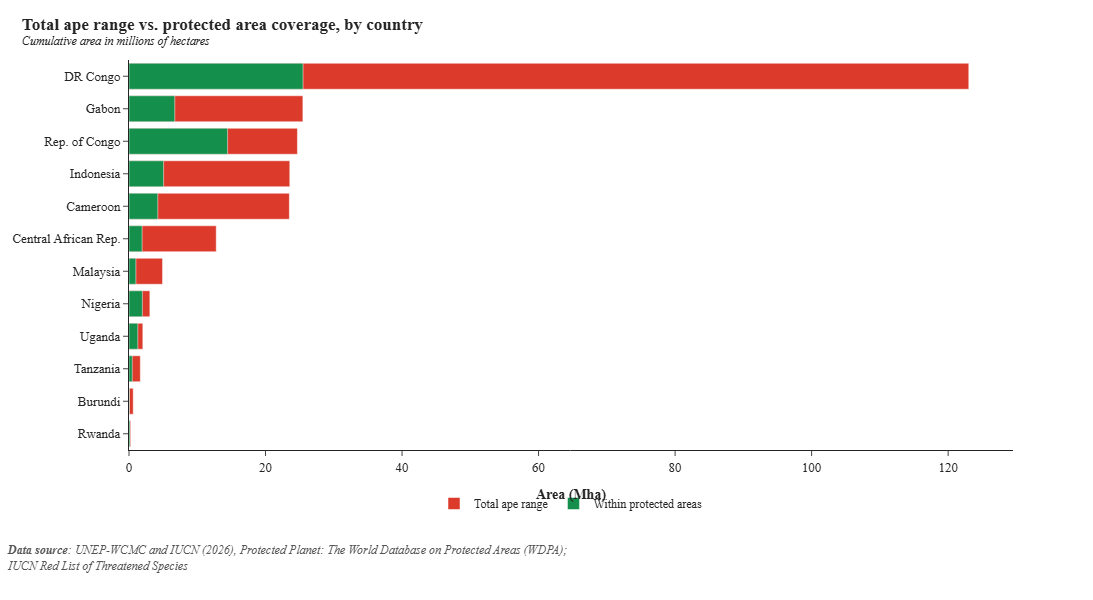

In [107]:
coverage_sorted2 = coverage_df.sort_values('range_area_mha', ascending=True)

fig_coverage_area = go.Figure()
fig_coverage_area.add_trace(go.Bar(
    x=coverage_sorted2['range_area_mha'],
    y=coverage_sorted2['country'],
    orientation='h',
    name='Total ape range',
    marker=dict(color='#DC3B2C'),
    hovertemplate='<b>%{y}</b><br>Total ape range: %{x:.2f} Mha<extra></extra>'
))
fig_coverage_area.add_trace(go.Bar(
    x=coverage_sorted2['pa_area_mha'],
    y=coverage_sorted2['country'],
    orientation='h',
    name='Within protected areas',
    marker=dict(color='#15904C'),
    hovertemplate='<b>%{y}</b><br>Protected area coverage: %{x:.2f} Mha<extra></extra>'
))
fig_coverage_area.update_layout(
    title=dict(
        text='<b>Total ape range vs. protected area coverage, by country</b><br>'
             '<sup><i>Cumulative area in millions of hectares</i></sup>',
        x=0.02
    ),
    template='simple_white',
    font_family='Roboto',
    height=600,
    margin=dict(t=60, b=150),
    width=755,
    autosize=False,
    barmode='overlay',
    xaxis=dict(
        title='<b>Area (Mha)</b>',
        tickfont=dict(size=13),
        fixedrange=True
    ),
    yaxis=dict(
        tickfont=dict(size=13),
        categoryorder='array',
        categoryarray=coverage_sorted2['country'].tolist()
    ),
    legend=dict(orientation='h', y=-0.1, x=0.5, xanchor='center'),
    dragmode=False,
    modebar_remove=['pan2d', 'select2d', 'lasso2d', 'zoom2d', 'zoomIn2d',
                    'zoomOut2d', 'autoScale', 'resetScale']
)
fig_coverage_area.update_layout(
    hoverlabel=dict(
        bgcolor='white',
        bordercolor='#333333',
        font_size=13,
        align='left'
    )
)
fig_coverage_area.add_annotation(
    text="<b>Data source</b>: UNEP-WCMC and IUCN (2026), Protected Planet: The World Database on Protected Areas (WDPA); <br>IUCN Red List of Threatened Species",
    xref='paper', yref='paper',
    x=-0.14, y=-0.32,
    showarrow=False,
    font=dict(size=12, color='#555555', style='italic'),
    xanchor='left',
    align='left'
)

fig_coverage_area.show()

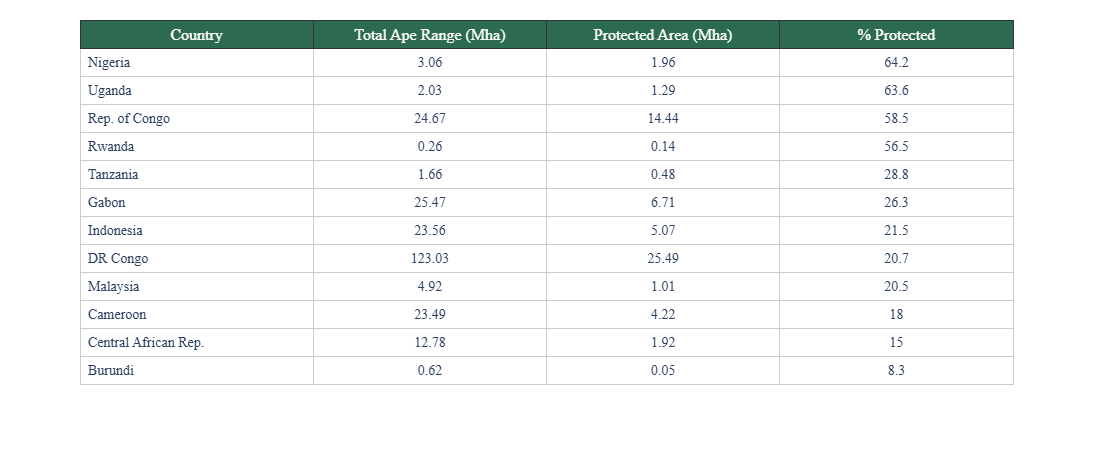

In [62]:
coverage_df = pd.read_csv(r"C:\Users\otmil\OneDrive - United Nations\Desktop\Career\Great Ape Conservation Project\pa_coverage_by_country.csv")
coverage_df['range_area_mha'] = coverage_df['range_area_ha'] / 1_000_000
coverage_df['pa_area_mha'] = coverage_df['pa_area_ha'] / 1_000_000
country_names = {
    'Democratic Republic of the Congo': 'DR Congo',
    'Republic of the Congo': 'Rep. of Congo',
    'Central African Republic': 'Central African Rep.'
}
coverage_df['country'] = coverage_df['country'].replace(country_names)

coverage_display = coverage_df[['country', 'range_area_mha', 'pa_area_mha', 'pct_covered']].copy()
coverage_display = coverage_display.sort_values('pct_covered', ascending=False)
coverage_display.columns = ['Country', 'Total Ape Range (Mha)', 'Protected Area (Mha)', '% Protected']

fig_coverage_table = go.Figure(data=[go.Table(
    header=dict(
        values=list(coverage_display.columns),
        fill_color='#2c6b4f',
        font=dict(color='white', size=16, family = 'Roboto'),
        line=dict(color= '#333333', width=1),
        align='center'
    ),
    cells=dict(
        values=[
            coverage_display['Country'],
            coverage_display['Total Ape Range (Mha)'].round(2),
            coverage_display['Protected Area (Mha)'].round(2),
            coverage_display['% Protected'].round(1)
        ],
        fill_color='white',
        font=dict(size=14, family = 'Roboto'),
        align=['left','center','center', 'center'],
        line=dict(color= '#cccccc', width=1),
        height=28
    )
)])
fig_coverage_table.update_layout(
    height=450,
    margin=dict(t=20, b=20)
)

In [46]:
coverage_df = pd.read_csv(r"C:\Users\otmil\OneDrive - United Nations\Desktop\Career\Great Ape Conservation Project\pa_coverage_by_country.csv")
print(coverage_df.columns.tolist())

['country', 'range_area_ha', 'pa_area_ha', 'pct_covered', 'range_area_mha', 'pa_area_mha']


In [63]:
print(coverage_display)
print(coverage_display.columns)
print(coverage_display.dtypes)

                 Country  Total Ape Range (Mha)  Protected Area (Mha)  \
4                Nigeria               3.055497              1.962169   
9                 Uganda               2.025613              1.289018   
5          Rep. of Congo              24.672619             14.443423   
6                 Rwanda               0.255147              0.144223   
8               Tanzania               1.660321              0.477357   
3                  Gabon              25.474189              6.705007   
10             Indonesia              23.556437              5.066403   
2               DR Congo             123.025114             25.489925   
11              Malaysia               4.915046              1.005940   
0               Cameroon              23.490805              4.217480   
1   Central African Rep.              12.779543              1.920391   
7                Burundi               0.617971              0.051043   

    % Protected  
4     64.217664  
9     63.63594

In [64]:
print(coverage_display["Country"].tolist())
print(coverage_display.columns.tolist())

['Nigeria', 'Uganda', 'Rep. of Congo', 'Rwanda', 'Tanzania', 'Gabon', 'Indonesia', 'DR Congo', 'Malaysia', 'Cameroon', 'Central African Rep.', 'Burundi']
['Country', 'Total Ape Range (Mha)', 'Protected Area (Mha)', '% Protected']


In [66]:
coverage_display = coverage_df[['country', 'range_area_mha', 'pa_area_mha', 'pct_covered']].copy()
coverage_display = coverage_display.sort_values('pct_covered', ascending=False)
coverage_display.columns = ['Country', 'Ape Range (Mha)', 'PA Coverage (Mha)', '% Protected']
coverage_display['Ape Range (Mha)'] = coverage_display['Ape Range (Mha)'].round(2)
coverage_display['PA Coverage (Mha)'] = coverage_display['PA Coverage (Mha)'].round(2)
coverage_display['% Protected'] = coverage_display['% Protected'].round(1)

print(coverage_display.to_markdown(index=False))

| Country              |   Ape Range (Mha) |   PA Coverage (Mha) |   % Protected |
|:---------------------|------------------:|--------------------:|--------------:|
| Nigeria              |              3.06 |                1.96 |          64.2 |
| Uganda               |              2.03 |                1.29 |          63.6 |
| Rep. of Congo        |             24.67 |               14.44 |          58.5 |
| Rwanda               |              0.26 |                0.14 |          56.5 |
| Tanzania             |              1.66 |                0.48 |          28.8 |
| Gabon                |             25.47 |                6.71 |          26.3 |
| Indonesia            |             23.56 |                5.07 |          21.5 |
| DR Congo             |            123.03 |               25.49 |          20.7 |
| Malaysia             |              4.92 |                1.01 |          20.5 |
| Cameroon             |             23.49 |                4.22 |          18   |
| Ce

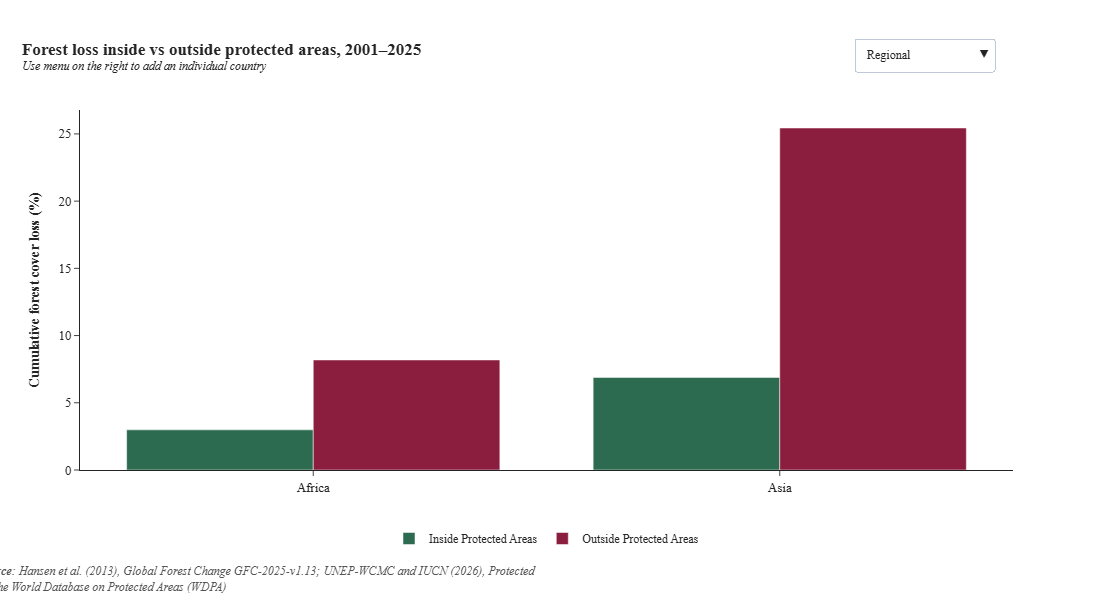

In [86]:
import pandas as pd
import plotly.graph_objects as go

# Load your combined, corrected country-level data
df = pd.read_csv(r"C:\Users\otmil\OneDrive - United Nations\Desktop\Career\Great Ape Conservation Project\pa_effectiveness_by_country_combined.csv")
# Recover raw loss pixel counts per year (needed to correctly sum across years)
df['loss_pixels_inside'] = (df['loss_pct_inside_pa'] / 100) * df['pixels_inside_pa']
df['loss_pixels_outside'] = (df['loss_pct_outside_pa'] / 100) * df['pixels_outside_pa']

# Cumulative totals per country (sum across all 25 years)
country_cumulative = df.groupby('country', as_index=False).agg(
    total_loss_inside=('loss_pixels_inside', 'sum'),
    total_loss_outside=('loss_pixels_outside', 'sum'),
    pixels_inside_pa=('pixels_inside_pa', 'first'),
    pixels_outside_pa=('pixels_outside_pa', 'first')
)
country_cumulative['pct_inside'] = (country_cumulative['total_loss_inside'] / country_cumulative['pixels_inside_pa']) * 100
country_cumulative['pct_outside'] = (country_cumulative['total_loss_outside'] / country_cumulative['pixels_outside_pa']) * 100

# --- Filter to only your 12 official ape range countries ---
ape_countries = ['Cameroon', 'Central African Republic', 'Democratic Republic of the Congo',
                  'Gabon', 'Nigeria', 'Republic of the Congo', 'Rwanda', 'Burundi',
                  'Tanzania', 'Uganda', 'Indonesia', 'Malaysia']

country_cumulative = country_cumulative[country_cumulative['country'].isin(ape_countries)].copy()

# Shortened names for display
country_names = {
    'Democratic Republic of the Congo': 'DR Congo',
    'Republic of the Congo': 'Rep. of Congo',
    'Central African Republic': 'Central African Rep.'
}
country_cumulative['display_name'] = country_cumulative['country'].replace(country_names)

# --- Regional totals (Africa / Asia) ---
africa_countries = ['Cameroon', 'Central African Republic', 'Democratic Republic of the Congo',
                     'Gabon', 'Nigeria', 'Republic of the Congo', 'Rwanda', 'Burundi',
                     'Tanzania', 'Uganda']
asia_countries = ['Indonesia', 'Malaysia']

def regional_pct(countries):
    subset = country_cumulative[country_cumulative['country'].isin(countries)]
    total_in = subset['total_loss_inside'].sum()
    total_out = subset['total_loss_outside'].sum()
    pix_in = subset['pixels_inside_pa'].sum()
    pix_out = subset['pixels_outside_pa'].sum()
    return (total_in / pix_in) * 100, (total_out / pix_out) * 100

africa_pct_in, africa_pct_out = regional_pct(africa_countries)
asia_pct_in, asia_pct_out = regional_pct(asia_countries)

# --- Build the chart ---
fig = go.Figure()

fig.add_trace(go.Bar(
    x=['Africa', 'Asia'],
    y=[africa_pct_in, asia_pct_in],
    name='Inside Protected Areas',
    marker_color='#2c6b4f',
    hovertemplate='<b>%{x}</b><br>Inside PAs: %{y:.1f}%<extra></extra>'
))
fig.add_trace(go.Bar(
    x=['Africa', 'Asia'],
    y=[africa_pct_out, asia_pct_out],
    name='Outside Protected Areas',
    marker_color='#8B1E3F',
    hovertemplate='<b>%{x}</b><br>Outside PAs: %{y:.1f}%<extra></extra>'
))

buttons = [
    dict(
        label='Regional',
        method='update',
        args=[
            {'x': [['Africa', 'Asia'], ['Africa', 'Asia']],
             'y': [[africa_pct_in, asia_pct_in], [africa_pct_out, asia_pct_out]]},
            {'title.text': '<b>Forest loss inside vs outside protected areas, 2001–2025</b><br><sup><i>Expressed as % of 2000 forest extent within great ape ranges</i></sup>'}
        ]
    )
]

for _, row in country_cumulative.iterrows():
    name = row['display_name']
    buttons.append(dict(
        label=name,
        method='update',
        args=[
            {'x': [['Africa', 'Asia', name], ['Africa', 'Asia', name]],
             'y': [[africa_pct_in, asia_pct_in, row['pct_inside']],
                   [africa_pct_out, asia_pct_out, row['pct_outside']]]},
            {'title.text': f'<b>Forest loss inside vs outside protected areas, 2001–2025</b><br><sup><i>Africa, Asia, and {name}</i></sup>'}
        ]
    ))

fig.update_layout(
    title=dict(
        text='<b>Forest loss inside vs outside protected areas, 2001–2025</b><br>'
             '<sup><i>Use menu on the right to add an individual country</i></sup>',
        x=0.02
    ),
    template='simple_white',
    font_family='Roboto',
    height=600,
    margin=dict(t=110, b=130),
    width=755,
    autosize=False,
    yaxis=dict(title='<b>Cumulative forest cover loss (%)</b>', tickfont=dict(size=13), fixedrange=True),
    xaxis=dict(tickfont=dict(size=13)),
    barmode='group',
    legend=dict(orientation='h', y=-0.15, x=0.5, xanchor='center'),
    dragmode=False,
    modebar_remove=['pan2d', 'select2d', 'lasso2d', 'zoom2d', 'zoomIn2d',
                    'zoomOut2d', 'autoScale', 'resetScale'],
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        x=0.98, y=1.2,
        showactive=True
    )]
)

fig.update_layout(
    hoverlabel=dict(
        bgcolor='white',
        bordercolor='#333333',
        font_size=13,
        align='left'
    )
)
fig.add_annotation(
    text="<b>Data source</b>: Hansen et al. (2013), Global Forest Change GFC-2025-v1.13; UNEP-WCMC and IUCN (2026), Protected <br>Planet: The World Database on Protected Areas (WDPA)",
    xref='paper', yref='paper',
    x=-0.14, y=-0.35,
    showarrow=False,
    font=dict(size=12, color='#555555', style='italic'),
    xanchor='left',
    align='left'
)

fig.show()

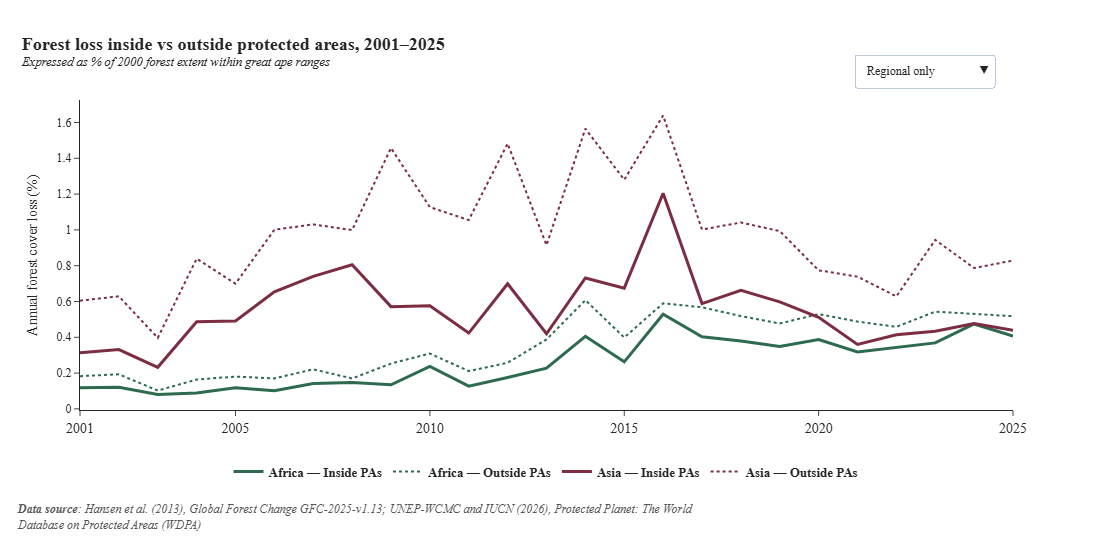

In [106]:

# --- LINE FIGURE with country selector ---

ape_countries = ['Cameroon', 'Central African Republic', 'Democratic Republic of the Congo',
                  'Gabon', 'Nigeria', 'Republic of the Congo', 'Rwanda', 'Burundi',
                  'Tanzania', 'Uganda', 'Indonesia', 'Malaysia']

country_names = {
    'Democratic Republic of the Congo': 'DR Congo',
    'Republic of the Congo': 'Rep. of Congo',
    'Central African Republic': 'Central African Rep.'
}

# Load your country-level annual data (with corrected percentages)
country_annual = pd.read_csv(r"C:\Users\otmil\OneDrive - United Nations\Desktop\Career\Great Ape Conservation Project\pa_effectiveness_by_country_combined.csv")
country_annual = country_annual[country_annual['country'].isin(ape_countries)].copy()
country_annual['display_name'] = country_annual['country'].replace(country_names)

fig_line_pa = go.Figure()

# --- Regional traces (always visible, indices 0-3) ---
fig_line_pa.add_trace(go.Scatter(
    x=africa['year'], y=africa['loss_pct_inside_pa'],
    name='<b>Africa — Inside PAs</b>',
    mode='lines', line=dict(color='#2d6a4f', width=3),
    hovertemplate='<b>Africa — Inside PAs</b><br>%{y:.2f}%<extra></extra>',
    visible=True
))
fig_line_pa.add_trace(go.Scatter(
    x=africa['year'], y=africa['loss_pct_outside_pa'],
    name='<b>Africa — Outside PAs</b>',
    mode='lines', line=dict(color='#2d6a4f', width=2, dash='dot'),
    hovertemplate='<b>Africa — Outside PAs</b><br>%{y:.2f}%<extra></extra>',
    visible=True
))
fig_line_pa.add_trace(go.Scatter(
    x=asia['year'], y=asia['loss_pct_inside_pa'],
    name='<b>Asia — Inside PAs</b>',
    mode='lines', line=dict(color='#7b2d42', width=3),
    hovertemplate='<b>Asia — Inside PAs</b><br>%{y:.2f}%<extra></extra>',
    visible=True
))
fig_line_pa.add_trace(go.Scatter(
    x=asia['year'], y=asia['loss_pct_outside_pa'],
    name='<b>Asia — Outside PAs</b>',
    mode='lines', line=dict(color='#7b2d42', width=2, dash='dot'),
    hovertemplate='<b>Asia — Outside PAs</b><br>%{y:.2f}%<extra></extra>',
    visible=True
))

# --- Country traces (one pair per country, hidden by default) ---
country_trace_start = len(fig_line_pa.data)  # index 4, where country traces begin

for country in ape_countries:
    subset = country_annual[country_annual['country'] == country].sort_values('year')
    name = subset['display_name'].iloc[0]

    fig_line_pa.add_trace(go.Scatter(
        x=subset['year'], y=subset['loss_pct_inside_pa'],
        name=f'<b>{name} — Inside PAs</b>',
        mode='lines', line=dict(color='#4472C4', width=3),
        hovertemplate=f'<b>{name} — Inside PAs</b><br>%{{y:.2f}}%<extra></extra>',
        visible=False
    ))
    fig_line_pa.add_trace(go.Scatter(
        x=subset['year'], y=subset['loss_pct_outside_pa'],
        name=f'<b>{name} — Outside PAs</b>',
        mode='lines', line=dict(color='#4472C4', width=2, dash='dot'),
        hovertemplate=f'<b>{name} — Outside PAs</b><br>%{{y:.2f}}%<extra></extra>',
        visible=False
    ))

# --- Build dropdown buttons ---
total_traces = len(fig_line_pa.data)

def visibility_mask(selected_country_idx=None):
    """First 4 (regional) always visible; only the selected country's pair visible."""
    mask = [True, True, True, True] + [False] * (total_traces - 4)
    if selected_country_idx is not None:
        pair_start = country_trace_start + (selected_country_idx * 2)
        mask[pair_start] = True
        mask[pair_start + 1] = True
    return mask

buttons = [
    dict(
        label='Regional only',
        method='restyle',
        args=[{'visible': visibility_mask()}]
    )
]

for i, country in enumerate(ape_countries):
    name = country_names.get(country, country)
    buttons.append(dict(
        label=name,
        method='restyle',
        args=[{'visible': visibility_mask(i)}]
    ))

# --- Layout ---
fig_line_pa.update_layout(
    width=755,
    autosize=False,
    title=dict(
        text='<b>Forest loss inside vs outside protected areas, 2001–2025</b><br>'
             '<sup><i>Expressed as % of 2000 forest extent within great ape ranges</i></sup>',
        x=0.02
    ),
    yaxis=dict(title='Annual forest cover loss (%)', showgrid=False),
    xaxis=dict(
        tickfont=dict(size=14),
        tickmode='array',
        tickvals=[2001, 2005, 2010, 2015, 2020, 2025],
        showgrid=False
    ),
    hoverlabel=dict(bgcolor='white', bordercolor='#333333', font_size=13, align='left'),
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        x=0.98, y=1.15,
        xanchor='right',
        showactive=True
    )],
    **LAYOUT_SHARED
)
fig_line_pa.add_annotation(
    text="<b>Data source</b>: Hansen et al. (2013), Global Forest Change GFC-2025-v1.13; UNEP-WCMC and IUCN (2026), Protected Planet: The World <br>Database on Protected Areas (WDPA)",
    xref='paper', yref='paper',
    x=-0.07, y=-0.40,
    showarrow=False,
    font=dict(size=12, color='#555555', style='italic'),
    xanchor='left',
    align='left'
)

fig_line_pa.show()

In [ ]:
# FULL CORRECTED TILE AUG 4 2026

def analyze_tile(lossyear_path, treecover_path, ape_ranges, protected_areas):
    
    with rasterio.open(lossyear_path) as src:
        bounds = src.bounds
        tile_bounds = box(bounds.left, bounds.bottom, bounds.right, bounds.top)
        src_transform = src.transform
        src_crs = src.crs
    
    # Filter to tile
    ape_tile = ape_ranges[ape_ranges.intersects(tile_bounds)]
    if len(ape_tile) == 0:
        print(f'No ape ranges in tile — skipping')
        return None
    
    pa_tile = protected_areas[protected_areas.intersects(tile_bounds)]
    
    # Dissolve overlapping species ranges within each country BEFORE processing,
    # so forest pixels where multiple species' ranges overlap (e.g. gorilla + 
    # chimp in Nigeria) are only counted once per country, not once per species.
    ape_tile = ape_tile.dissolve(by='country').reset_index()
    
    # Per-country accumulators
    country_data = {}
    
    for idx, ape_row in ape_tile.iterrows():
        country = ape_row['country']
        geom = ape_row.geometry
        geom_bounds = geom.bounds
        
        if country not in country_data:
            country_data[country] = {
                'year_loss_inside': np.zeros(25, dtype=np.int64),
                'year_loss_outside': np.zeros(25, dtype=np.int64),
                'total_inside': 0,
                'total_outside': 0
            }
        
        # Read just the window for this single (now dissolved) geometry
        with rasterio.open(lossyear_path) as src:
            window = from_bounds(geom_bounds[0], geom_bounds[1], 
                               geom_bounds[2], geom_bounds[3], 
                               src.transform)
            loss_chunk = src.read(1, window=window)
            win_transform = src.window_transform(window)
        
        with rasterio.open(treecover_path) as src:
            window = from_bounds(geom_bounds[0], geom_bounds[1],
                               geom_bounds[2], geom_bounds[3],
                               src.transform)
            tc_chunk = src.read(1, window=window)
        
        # Masks for this country's dissolved range geometry
        from rasterio.features import rasterize
        ape_mask = rasterize(
            [(geom, 1)],
            out_shape=loss_chunk.shape,
            transform=win_transform,
            fill=0,
            dtype='uint8'
        )
        
        # PAs intersecting this geometry
        pa_here = pa_tile[pa_tile.intersects(geom)]
        if len(pa_here) > 0:
            pa_mask = rasterize(
                [(g, 1) for g in pa_here.geometry],
                out_shape=loss_chunk.shape,
                transform=win_transform,
                fill=0,
                dtype='uint8'
            )
        else:
            pa_mask = np.zeros(loss_chunk.shape, dtype='uint8')
        
        # Valid forest pixels within this country's range
        valid_forest = (ape_mask == 1) & (tc_chunk >= 10) & (tc_chunk != 255) & (loss_chunk != 255)
        
        inside = valid_forest & (pa_mask == 1)
        outside = valid_forest & (pa_mask == 0)
        
        country_data[country]['total_inside'] += int(np.sum(inside))
        country_data[country]['total_outside'] += int(np.sum(outside))
        
        for year_idx in range(1, 26):
            country_data[country]['year_loss_inside'][year_idx-1] += np.count_nonzero((loss_chunk == year_idx) & inside)
            country_data[country]['year_loss_outside'][year_idx-1] += np.count_nonzero((loss_chunk == year_idx) & outside)
        
        del loss_chunk, tc_chunk, ape_mask, pa_mask, valid_forest, inside, outside
    
    # Build results
    results = []
    for country, data in country_data.items():
        for year_idx in range(25):
            pct_inside = (data['year_loss_inside'][year_idx] / data['total_inside'] * 100) if data['total_inside'] > 0 else 0
            pct_outside = (data['year_loss_outside'][year_idx] / data['total_outside'] * 100) if data['total_outside'] > 0 else 0
            results.append({
                'country': country,
                'year': 2001 + year_idx,
                'loss_pct_inside_pa': pct_inside,
                'loss_pct_outside_pa': pct_outside,
                'pixels_inside_pa': data['total_inside'],
                'pixels_outside_pa': data['total_outside']
            })
    
    print(f'Tile complete: {lossyear_path.split(chr(92))[-1]}')
    return pd.DataFrame(results)